In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#990000""","""LOFTEE HC""",1
"""plof""","""consequence_stop_gained""","""#CC0000""","""Stop Gained""",1
"""plof""","""consequence_splice_acceptor_va…","""#FF3333""","""Splice Acceptor""",1
"""plof""","""consequence_splice_donor_varia…","""#FF6666""","""Splice Donor""",1
"""plof""","""consequence_stop_lost""","""#FF9999""","""Stop Lost""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [3]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251122.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251122_fillna.parquet")

min_range = -10_000
max_range = +0

anno = (
    anno
    .filter(
        # (pl.col('vep_cds') == True)
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True))
        # (pl.col('non_mane_cds') == False)

        # (pl.col('consequence_5_prime_utr_variant')==True)

        (pl.col('dist_to_tss') < max_range) &
        (pl.col('dist_to_tss') > min_range)
    )
    .with_columns(
        encode_annotated = pl.col('not_in_encode')==False,
        insertion = pl.when(pl.col('ref').str.len_chars() < pl.col('alt').str.len_chars()).then(True).otherwise(False),
        deletion = pl.when(pl.col('ref').str.len_chars() > pl.col('alt').str.len_chars()).then(True).otherwise(False),
    )
    .with_columns(
        short_insertion = pl.when(pl.col('variant_length') == 2).then(True).otherwise(False) & pl.col('insertion'),
        short_deletion = pl.when(pl.col('variant_length') == 2).then(True).otherwise(False) & pl.col('deletion'),
        medium_insertion = pl.when((pl.col('variant_length') >= 3) & (pl.col('variant_length') <= 4)).then(True).otherwise(False) & pl.col('insertion'),
        medium_deletion = pl.when((pl.col('variant_length') >= 3) & (pl.col('variant_length') <= 4)).then(True).otherwise(False) & pl.col('deletion'),
        long_insertion = pl.when(pl.col('variant_length') > 4).then(True).otherwise(False) & pl.col('insertion'),
        long_deletion = pl.when(pl.col('variant_length')  > 4).then(True).otherwise(False) & pl.col('deletion'),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

long_insertion,id,five_prime_utr_variant_consequence_ustop_lost,encode_ca_h3k4me3,consequence_splice_acceptor_variant,encode_ca_ctcf,medium_deletion,encode_pls,consequence_frameshift_variant,strand,encode_pels,encode_ca_tf,dist_to_tss,consequence_missense_variant,loftee_hc,five_prime_utr_variant_consequence_uaug_gained,gene_length,consequence_splice_donor_variant,encode_annotated,five_prime_utr_variant_consequence_ustop_gained,deletion,medium_insertion,consequence_stop_lost,region,tss,encode_tf,consequence_stop_gained,encode_ca,encode_dels,five_prime_utr_variant_consequence_uaug_lost,not_in_encode,short_deletion,insertion,gene_name,five_prime_utr_variant_consequence_uframeshift,long_deletion,consequence_start_lost,short_insertion
bool,str,u8,bool,i32,bool,bool,bool,i32,str,bool,bool,i64,i32,i8,u8,i64,i32,bool,u8,bool,bool,i32,str,i64,bool,i32,bool,bool,u8,bool,bool,bool,str,u8,bool,i32,bool
false,"""chr20:50692825:A:C""",0,false,0,false,false,false,0,"""-1""",true,false,-1283,0,0,0,105436,0,true,0,false,false,0,"""ENSG00000042062""",50691542,false,0,false,false,0,false,false,false,"""RIPOR3""",0,false,0,false
false,"""chr20:50695278:T:C""",0,false,0,false,false,false,0,"""-1""",false,false,-3736,0,0,0,105436,0,true,0,false,false,0,"""ENSG00000042062""",50691542,false,0,false,true,0,false,false,false,"""RIPOR3""",0,false,0,false
false,"""chr20:50695956:T:C""",0,false,0,false,false,false,0,"""-1""",false,false,-4414,0,0,0,105436,0,false,0,false,false,0,"""ENSG00000042062""",50691542,false,0,false,false,0,true,false,false,"""RIPOR3""",0,false,0,false
false,"""chr20:50694514:G:A""",0,false,0,false,false,false,0,"""-1""",false,false,-2972,0,0,0,105436,0,true,0,false,false,0,"""ENSG00000042062""",50691542,false,0,false,true,0,false,false,false,"""RIPOR3""",0,false,0,false
false,"""chr20:50693075:C:G""",0,false,0,false,false,false,0,"""-1""",true,false,-1533,0,0,0,105436,0,true,0,false,false,0,"""ENSG00000042062""",50691542,false,0,false,false,0,false,false,false,"""RIPOR3""",0,false,0,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
true,"""chr17:69143864:G:GATAGATAGATAC""",0,false,0,false,false,false,0,"""-1""",false,false,-1969,0,0,0,63195,0,false,0,false,false,0,"""ENSG00000154262""",69141895,false,0,false,false,0,true,false,true,"""ABCA6""",0,false,0,false
false,"""chr19:4523078:CTTT:C""",0,false,0,false,true,false,0,"""-1""",false,false,-4592,0,0,0,16296,0,false,0,true,false,0,"""ENSG00000167676""",4518486,false,0,false,false,0,true,false,false,"""PLIN4""",0,false,0,false
true,"""chr12:124883361:G:GAGAA""",0,false,0,false,false,false,0,"""-1""",false,false,-693,0,0,0,105814,0,false,0,false,false,0,"""ENSG00000073060""",124882668,false,0,false,false,0,true,false,true,"""SCARB1""",0,false,0,false


In [4]:
print(anno['short_deletion'].sum(), anno['medium_deletion'].sum(), anno['long_deletion'].sum())

34724 22970 27266


In [5]:
print(anno['short_insertion'].sum(), anno['medium_insertion'].sum(), anno['long_insertion'].sum())

21732 10193 23212


In [6]:
melted_anno = (
    anno
    # .with_columns(
    #     am_pathogenicity = pl.col('am_pathogenicity') >= 0.8
    # )

    .unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
    )

    .filter(
        # pl.col('category').is_in(['indel_length']) # upstream
        # pl.col('category').is_in(['encode_enhancer']) # upstream
        pl.col('category').is_in(['encode_boolean', 'indel_categories']) # upstream
        # pl.col('category').is_in(['indel_categories', 'plof', 'missense']) # CDS
        # pl.col('category').is_in(['indel_categories', '5utr_annotator', 'encode_boolean']) # 5utr
    )

    # .drop_nulls()
    # .filter(pl.col('annotation_score').is_not_null())
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor
str,str,str,f32,str,str,str,i64,f64
"""chr20:50692825:A:C""","""ENSG00000042062""","""consequence_frameshift_variant""",0.0,"""indel_categories""","""#00A99D""","""VEP Frameshift""",1,0.0
"""chr20:50695278:T:C""","""ENSG00000042062""","""consequence_frameshift_variant""",0.0,"""indel_categories""","""#00A99D""","""VEP Frameshift""",1,0.0
"""chr20:50695956:T:C""","""ENSG00000042062""","""consequence_frameshift_variant""",0.0,"""indel_categories""","""#00A99D""","""VEP Frameshift""",1,0.0
"""chr20:50694514:G:A""","""ENSG00000042062""","""consequence_frameshift_variant""",0.0,"""indel_categories""","""#00A99D""","""VEP Frameshift""",1,0.0
"""chr20:50693075:C:G""","""ENSG00000042062""","""consequence_frameshift_variant""",0.0,"""indel_categories""","""#00A99D""","""VEP Frameshift""",1,0.0
…,…,…,…,…,…,…,…,…
"""chr17:69143864:G:GATAGATAGATAC""","""ENSG00000154262""","""encode_annotated""",0.0,"""encode_boolean""","""peru""","""Variant in ENCODE annotated re…",1,0.0
"""chr19:4523078:CTTT:C""","""ENSG00000167676""","""encode_annotated""",0.0,"""encode_boolean""","""peru""","""Variant in ENCODE annotated re…",1,0.0
"""chr12:124883361:G:GAGAA""","""ENSG00000073060""","""encode_annotated""",0.0,"""encode_boolean""","""peru""","""Variant in ENCODE annotated re…",1,0.0


In [7]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [8]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [10]:
n_steps = 101
or_threshold_pheno_high = 0.5
or_threshold_pheno_low = 1e-3

cutoffs_list = 1 - np.logspace(
    np.log10(or_threshold_pheno_low),
    np.log10(or_threshold_pheno_high),
    num=n_steps
)

pheno_cutoffs_lazy = pl.LazyFrame({"pheno_cutoff": cutoffs_list.tolist()})

pheno_cutoffs_lazy.collect()

pheno_cutoff
f64
0.999
0.998936
0.998868
0.998795
0.998718
…
0.610048
0.585045
0.558439


In [11]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    # Select required variants
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    #Merge annotation scores
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    # Merge with gene_trait_df
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        # mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
        #     .then(1 - pl.col('mean_pheno_value_ptile'))
        #     .otherwise(pl.col('mean_pheno_value_ptile')),
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1) # To get 1/100, 1/1000, etc.
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )

    # .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor", "mean_pheno_value_dircor_ptile"])
    
    # Cross join with cutoffs and compute odds ratios
    .join(
        pheno_cutoffs_lazy, 
        how="cross"
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "pheno_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = gp_lazy.collect(engine='streaming').sort('pheno_cutoff')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,pheno_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""insertion""","""ENSG00000167701""","""GPT""","""alanine_aminotransferase_int""",0.5,16,23,859,835,0.676216
"""deletion""","""ENSG00000171714""","""ANO5""","""alanine_aminotransferase_int""",0.5,41,31,558,553,1.31073
"""encode_annotated""","""ENSG00000171714""","""ANO5""","""alanine_aminotransferase_int""",0.5,110,118,489,466,0.888357
"""deletion""","""ENSG00000163631""","""ALB""","""albumin_int""",0.5,23,24,491,516,1.007128
"""consequence_frameshift_variant""","""ENSG00000073734""","""ABCB11""","""alkaline_phosphatase_int""",0.5,0,0,535,570,NaN
…,…,…,…,…,…,…,…,…,…
"""not_in_encode""","""ENSG00000169047""","""IRS1""","""arm_predicted_mass_left_int""",0.999,1,519,0,808,inf
"""encode_annotated""","""ENSG00000080345""","""RIF1""","""weight_int""",0.999,0,429,2,724,0.0
"""encode_annotated""","""ENSG00000022840""","""RNF10""","""high_light_scatter_reticulocyt…",0.999,0,582,0,605,NaN


In [49]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['pheno_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['pheno_cutoff', 'annotation']),
        pheno_cutoff_inv = 1 - pl.col('pheno_cutoff'),
    )
    .with_columns(
        neg_log_pheno_cutoff_inv = -np.log10(pl.col('pheno_cutoff_inv')),
        med_odds_ratio = pl.col('odds_ratio').median().over(['pheno_cutoff_inv', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['pheno_cutoff_inv', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['pheno_cutoff_inv', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'neg_log_pheno_cutoff_inv', 'pheno_cutoff', 'pheno_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    
    # join plotting info
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('pheno_cutoff_inv')
)

plt_df

unique percentile cutoffs: 101


annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str
"""insertion""",3.0,0.999,0.001,814,0.0,0.71566,0.155729,1.020889,0.410431,"""#1E90FF""","""Insertion"""
"""not_in_encode""",3.0,0.999,0.001,453,0.0,0.589349,0.042947,0.673525,0.505172,"""black""","""Not annotated in ENCODE annota…"
"""encode_annotated""",3.0,0.999,0.001,585,0.0,0.533721,0.04212,0.616276,0.451167,"""peru""","""Variant in ENCODE annotated re…"
"""deletion""",3.0,0.999,0.001,790,0.0,0.93713,0.138185,1.207973,0.666287,"""#2E8B57""","""Deletion"""
"""insertion""",2.97301,0.998936,0.001064,837,0.0,0.775218,0.160741,1.090271,0.460166,"""#1E90FF""","""Insertion"""
…,…,…,…,…,…,…,…,…,…,…,…
"""deletion""",0.32802,0.530127,0.469873,1175,0.998632,1.017709,0.007638,1.03268,1.002738,"""#2E8B57""","""Deletion"""
"""insertion""",0.30103,0.5,0.5,1175,1.043478,1.096147,0.010522,1.116771,1.075524,"""#1E90FF""","""Insertion"""
"""encode_annotated""",0.30103,0.5,0.5,1174,1.001108,1.011791,0.003903,1.019441,1.004142,"""peru""","""Variant in ENCODE annotated re…"


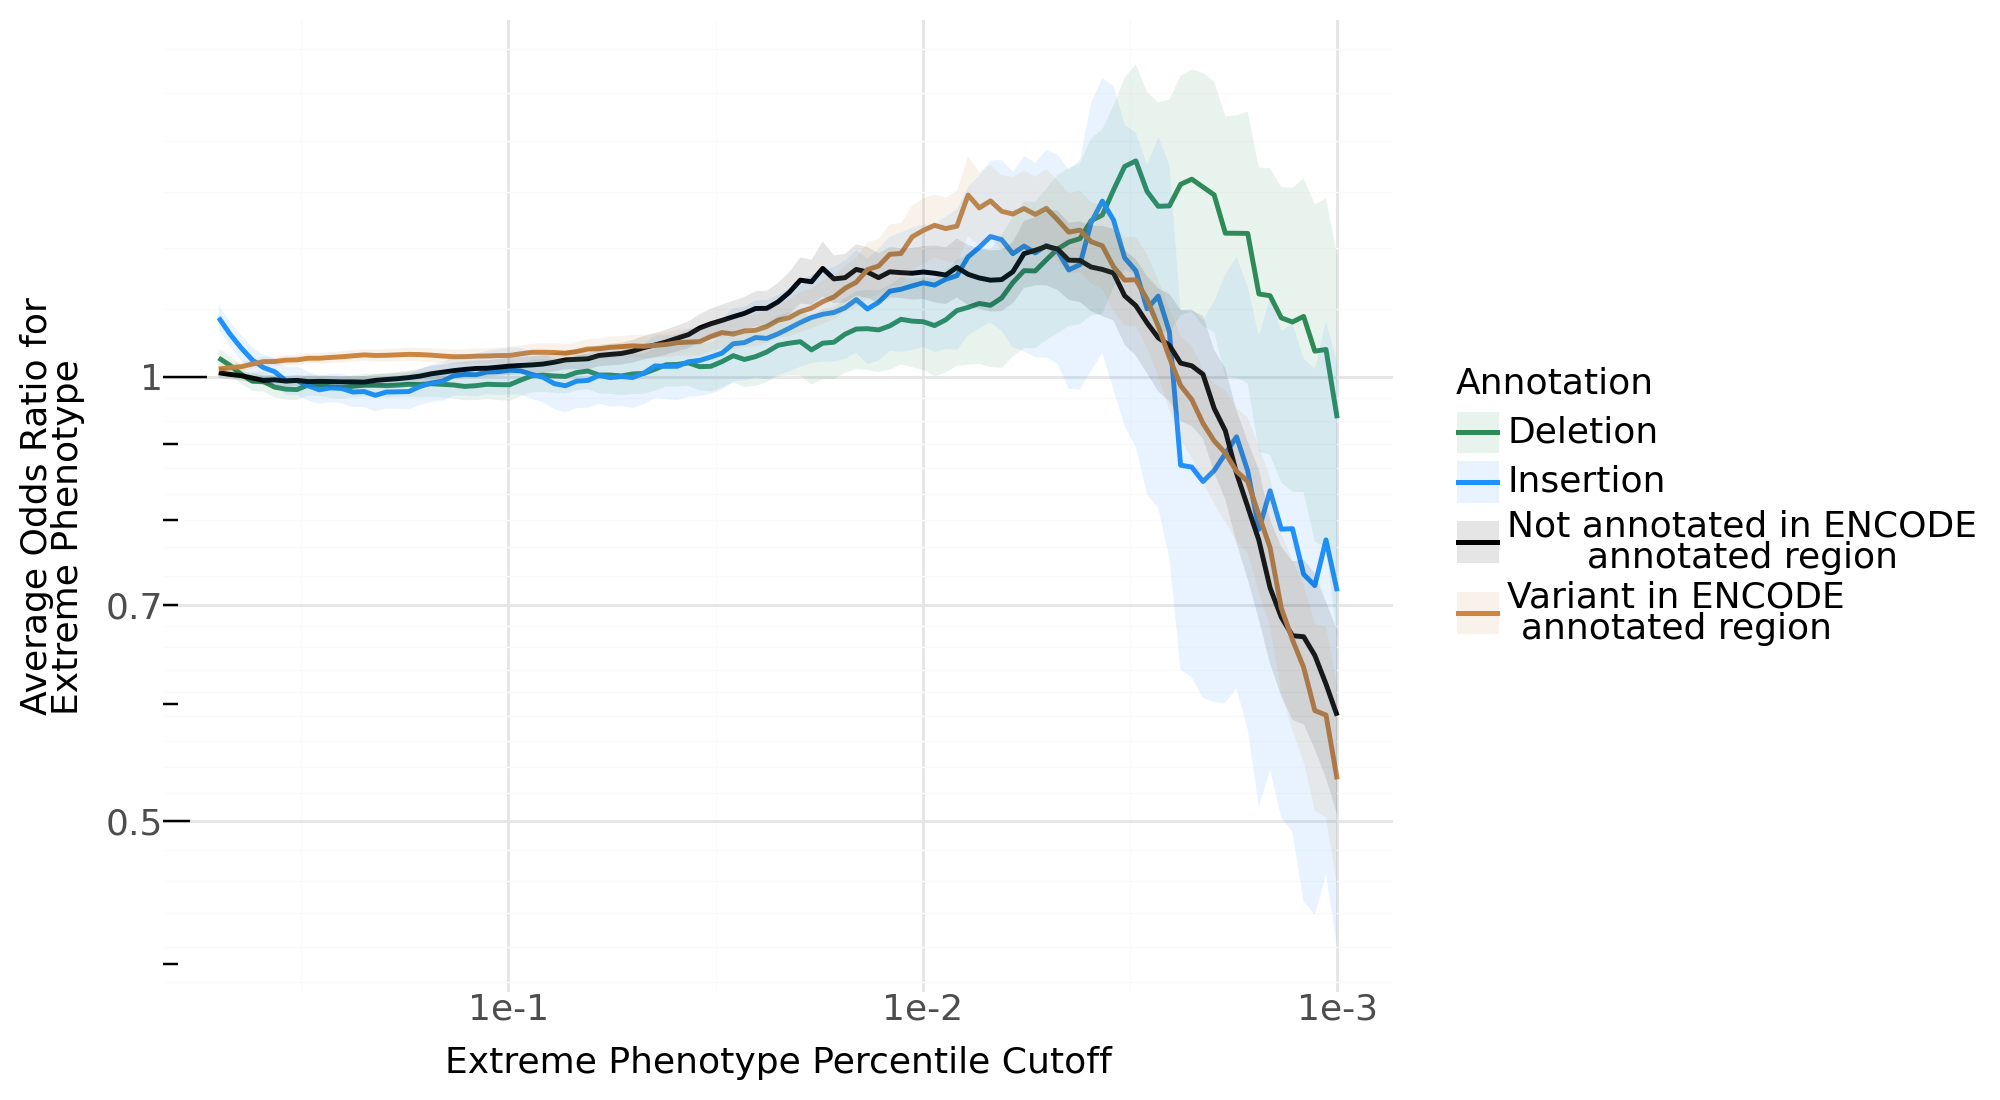

In [ ]:
# Generate breaks and labels for x-axis
start_exp = int(-np.log10(or_threshold_pheno_high))
end_exp = int(-np.log10(or_threshold_pheno_low))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e-{b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plt_df,
        aes(x='neg_log_pheno_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y=f"Average Odds Ratio for\nExtreme Phenotype",
        x="Extreme Phenotype Percentile Cutoff",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="l")
    + theme_minimal()
    + theme(
        figure_size=(10, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

In [53]:
plt_df.sort('avg_odds_ratio')

annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str
"""encode_annotated""",3.0,0.999,0.001,585,0.0,0.533721,0.04212,0.616276,0.451167,"""peru""","""Variant in ENCODE annotated re…"
"""not_in_encode""",3.0,0.999,0.001,453,0.0,0.589349,0.042947,0.673525,0.505172,"""black""","""Not annotated in ENCODE annota…"
"""encode_annotated""",2.97301,0.998936,0.001064,614,0.0,0.589962,0.044482,0.677147,0.502777,"""peru""","""Variant in ENCODE annotated re…"
"""encode_annotated""",2.946021,0.998868,0.001132,644,0.0,0.594092,0.043801,0.679942,0.508242,"""peru""","""Variant in ENCODE annotated re…"
"""not_in_encode""",2.97301,0.998936,0.001064,471,0.221753,0.619167,0.04322,0.703878,0.534456,"""black""","""Not annotated in ENCODE annota…"
…,…,…,…,…,…,…,…,…,…,…,…
"""deletion""",2.676124,0.997892,0.002108,1081,0.0,1.343723,0.133295,1.60498,1.082465,"""#2E8B57""","""Deletion"""
"""deletion""",2.622144,0.997613,0.002387,1111,0.0,1.349443,0.127071,1.598502,1.100384,"""#2E8B57""","""Deletion"""
"""deletion""",2.649134,0.997757,0.002243,1098,0.0,1.360307,0.12951,1.614147,1.106467,"""#2E8B57""","""Deletion"""
